In [1]:
! pip install tensorflow streamlit pandas numpy scikit-learn plotly matplotlib

Defaulting to user installation because normal site-packages is not writeable
  Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl.metadata (4.5 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached setuptools-82.0.1-py3-none-any.whl.metadata (6.5 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached wrapt-2.1.2-cp313-cp313-win_amd64.whl.metadata (7.6 kB)
  Using cached grpcio-1.80.0-cp313-cp313-win_amd64.whl.metadata (3.9 kB)
  Using cached keras-3.14.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached h5p

ERROR: Could not install packages due to an OSError: [Errno 2] No such file or directory: 'C:\\Users\\lenovo\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python313\\site-packages\\tensorflow\\include\\external\\com_github_grpc_grpc\\src\\core\\credentials\\call\\gcp_service_account_identity\\gcp_service_account_identity_credentials.h'
HINT: This error might have occurred since this system does not have Windows Long Path support enabled. You can find information on how to enable this at https://pip.pypa.io/warnings/enable-long-paths



In [2]:
import os

os.makedirs("data",   exist_ok=True)
os.makedirs("models", exist_ok=True)
os.makedirs("utils",  exist_ok=True)
print("✅ Folders created")

✅ Folders created


In [3]:
with open("utils/__init__.py", "w") as f:
    f.write("# utils package\n")
print("✅ utils/__init__.py created")

✅ utils/__init__.py created


In [4]:
code = '''import re

def clean_text(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"http\\S+|www\\S+", " ", text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"\\n|\\r|\\t", " ", text)
    text = re.sub(r"[^a-z0-9\\s!?.,\\'']", " ", text)
    text = re.sub(r"\\s+", " ", text).strip()
    return text
'''

with open("utils/preprocess.py", "w") as f:
    f.write(code)
print("✅ utils/preprocess.py created")

✅ utils/preprocess.py created


In [5]:
code = '''import pickle
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from utils.preprocess import clean_text

LABEL_COLS = ["toxic","severe_toxic","obscene","threat","insult","identity_hate"]
MAX_LEN    = 200
THRESHOLD  = 0.5

def load_artifacts():
    model = load_model("models/toxicity_model.h5")
    with open("models/tokenizer.pkl", "rb") as f:
        tokenizer = pickle.load(f)
    return model, tokenizer

def predict_single(text, model, tokenizer):
    cleaned = clean_text(text)
    seq     = tokenizer.texts_to_sequences([cleaned])
    padded  = pad_sequences(seq, maxlen=MAX_LEN)
    probs   = model.predict(padded, verbose=0)[0]
    result  = {label: float(prob) for label, prob in zip(LABEL_COLS, probs)}
    result["is_toxic"]       = any(p >= THRESHOLD for p in probs)
    result["dominant_label"] = LABEL_COLS[int(np.argmax(probs))] if result["is_toxic"] else "clean"
    return result

def predict_batch(texts, model, tokenizer):
    cleaned = [clean_text(t) for t in texts]
    seqs    = tokenizer.texts_to_sequences(cleaned)
    padded  = pad_sequences(seqs, maxlen=MAX_LEN)
    probs   = model.predict(padded, verbose=0)
    df_out  = pd.DataFrame(probs, columns=LABEL_COLS)
    df_out.insert(0, "comment_text", texts)
    df_out["is_toxic"]       = (probs >= THRESHOLD).any(axis=1)
    df_out["dominant_label"] = [
        LABEL_COLS[int(np.argmax(row))] if any(p >= THRESHOLD for p in row) else "clean"
        for row in probs
    ]
    return df_out
'''

with open("utils/predict.py", "w") as f:
    f.write(code)
print("✅ utils/predict.py created")

✅ utils/predict.py created


In [1]:
import pandas as pd

df = pd.read_csv("train.csv")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head(3)

Shape: (159571, 8)
Columns: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0


In [2]:
import matplotlib.pyplot as plt

LABEL_COLS = ["toxic","severe_toxic","obscene","threat","insult","identity_hate"]
total = len(df)

print("Label Distribution:")
print("-" * 50)
for col in LABEL_COLS:
    count = int(df[col].sum())
    pct   = count / total * 100
    bar   = "█" * int(pct * 2)
    print(f"  {col:20s} {count:6,}  ({pct:4.1f}%)  {bar}")

clean = int((df[LABEL_COLS].sum(axis=1) == 0).sum())
print(f"  {'clean':20s} {clean:6,}  ({clean/total*100:4.1f}%)")

df["char_len"] = df["comment_text"].fillna("").apply(len)
print(f"\nComment Length Stats:\n{df['char_len'].describe().round(1)}")

Label Distribution:
--------------------------------------------------
  toxic                15,294  ( 9.6%)  ███████████████████
  severe_toxic          1,595  ( 1.0%)  █
  obscene               8,449  ( 5.3%)  ██████████
  threat                  478  ( 0.3%)  
  insult                7,877  ( 4.9%)  █████████
  identity_hate         1,405  ( 0.9%)  █
  clean                143,346  (89.8%)

Comment Length Stats:
count    159571.0
mean        394.1
std         590.7
min           6.0
25%          96.0
50%         205.0
75%         435.0
max        5000.0
Name: char_len, dtype: float64


C:\Users\lenovo\AppData\Local\Temp\ipykernel_7792\1352874560.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(LABEL_COLS, rotation=30, ha="right", fontsize=8)


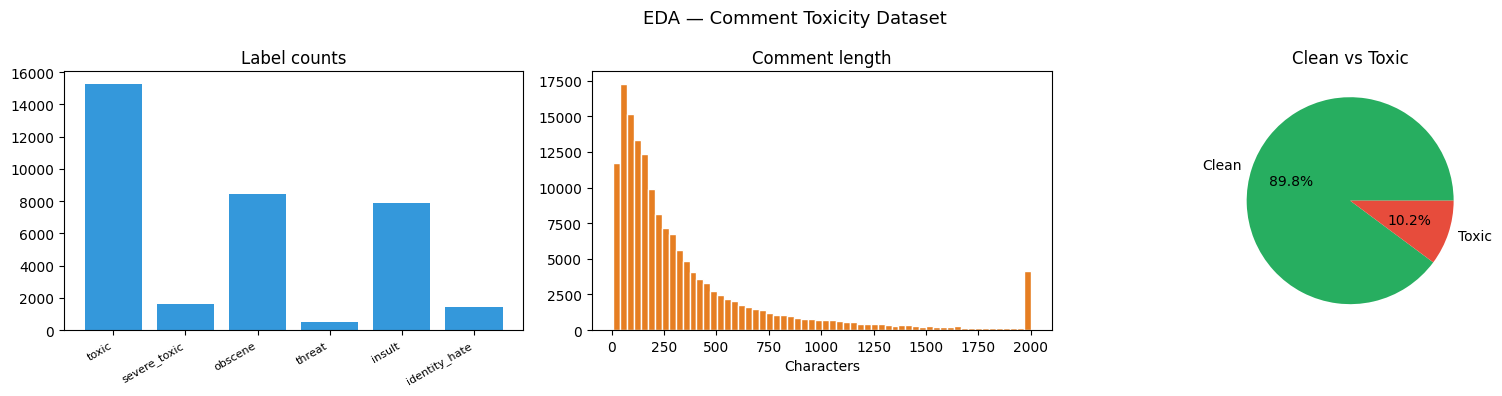

✅ EDA chart saved → eda_report.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("EDA — Comment Toxicity Dataset", fontsize=13)

# Label counts
axes[0].bar(LABEL_COLS, df[LABEL_COLS].sum().values, color="#3498db")
axes[0].set_title("Label counts")
axes[0].set_xticklabels(LABEL_COLS, rotation=30, ha="right", fontsize=8)

# Comment length
axes[1].hist(df["char_len"].clip(0, 2000), bins=60, color="#e67e22", edgecolor="white")
axes[1].set_title("Comment length")
axes[1].set_xlabel("Characters")

# Clean vs Toxic pie
any_toxic = (df[LABEL_COLS].sum(axis=1) > 0).sum()
axes[2].pie([total - any_toxic, any_toxic],
            labels=["Clean", "Toxic"],
            colors=["#27ae60", "#e74c3c"],
            autopct="%1.1f%%")
axes[2].set_title("Clean vs Toxic")

plt.tight_layout()
plt.savefig("eda_report.png", dpi=120)
plt.show()
print("✅ EDA chart saved → eda_report.png")

In [3]:
import re
import sys
sys.path.insert(0, ".")
from utils.preprocess import clean_text

df["comment_text"] = df["comment_text"].fillna("").apply(clean_text)
print("✅ Text cleaned")
print("\nSample cleaned comment:")
print(df["comment_text"].iloc[0])

✅ Text cleaned

Sample cleaned comment:
explanation why the edits made under my username hardcore metallica fan were reverted? they weren't vandalisms, just closure on some gas after i voted at new york dolls fac. and please don't remove the template from the talk page since i'm retired now.89.205.38.27


In [4]:

! pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable


In [6]:
! pip install -q --upgrade scikit-learn numpy

  You can safely remove it manually.
  You can safely remove it manually.


In [ ]:
# Check versions
import sklearn
import numpy as np
import sys
print("Python:", sys.version)
print("sklearn:", sklearn.__version__)
print("numpy:", np.__version__)

Python: 3.13.13 (tags/v3.13.13:01104ce, Apr  7 2026, 19:25:48) [MSC v.1944 64 bit (AMD64)]
sklearn: 1.8.0
numpy: 2.4.4


In [2]:
! pip install "numpy<2.0" --force-reinstall -q

  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [21 lines of output]
      + C:\Users\lenovo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe C:\Users\lenovo\AppData\Local\Temp\pip-install-l7iteuqf\numpy_7e78b53e43854ff4889f401478ac18fe\vendored-meson\meson\meson.py setup C:\Users\lenovo\AppData\Local\Temp\pip-install-l7iteuqf\numpy_7e78b53e43854ff4889f401478ac18fe C:\Users\lenovo\AppData\Local\Temp\pip-install-l7iteuqf\numpy_7e78b53e43854ff4889f401478ac18fe\.mesonpy-1dmbsxk0 -Dbuildtype=release -Db_ndebug=if-release -Db_vscrt=md --native-file=C:\Users\lenovo\AppData\Local\Temp\pip-install-l7iteuqf\numpy_7e78b53e43854ff4889f401478ac18fe\.mesonpy-1dmbsxk0\meson-python-native-file.ini
      The Meson build system
      Version: 1.2.99
      Source dir: C:\Users\lenovo\AppData\Local\Temp\pip-install-l7iteuqf\numpy_7e78b53e43854ff4889f401478ac18fe
      Build d

In [6]:
import pickle
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from utils.preprocess import clean_text

LABEL_COLS = ["toxic","severe_toxic","obscene","threat","insult","identity_hate"]
MAX_VOCAB  = 50_000
MAX_LEN    = 200

# Reload data
df = pd.read_csv("train.csv")
df["comment_text"] = df["comment_text"].fillna("").apply(clean_text)
print(f"✅ Data loaded: {len(df):,} rows")

X = df["comment_text"].values
y = df[LABEL_COLS].values.astype(np.float32)

# Manual 90/10 split — no sklearn needed
np.random.seed(42)
indices   = np.random.permutation(len(X))
split     = int(len(X) * 0.9)
X_train   = X[indices[:split]]
X_val     = X[indices[split:]]
y_train   = y[indices[:split]]
y_val     = y[indices[split:]]

print(f"✅ Train: {len(X_train):,}  |  Val: {len(X_val):,}")

# Tokenize
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=MAX_LEN)
X_val_seq   = pad_sequences(tokenizer.texts_to_sequences(X_val),   maxlen=MAX_LEN)

with open("models/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print("✅ Tokenizer saved")
print(f"X_train_seq shape: {X_train_seq.shape}")
print(f"X_val_seq shape:   {X_val_seq.shape}")

✅ Data loaded: 159,571 rows
✅ Train: 143,613  |  Val: 15,958
✅ Tokenizer saved
X_train_seq shape: (143613, 200)
X_val_seq shape:   (15958, 200)


In [7]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, Bidirectional, LSTM,
    Dense, Dropout, GlobalMaxPooling1D
)

EMBED_DIM = 128

def build_model(vocab_size, embed_dim, max_len, num_labels):
    inp = Input(shape=(max_len,))
    x   = Embedding(vocab_size, embed_dim, trainable=True)(inp)
    x   = Bidirectional(LSTM(64, return_sequences=True))(x)
    x   = GlobalMaxPooling1D()(x)
    x   = Dense(64, activation="relu")(x)
    x   = Dropout(0.3)(x)
    out = Dense(num_labels, activation="sigmoid")(x)
    model = Model(inp, out)
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

model = build_model(MAX_VOCAB + 1, EMBED_DIM, MAX_LEN, len(LABEL_COLS))
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 200, 128)       │     6,400,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 200, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,507,590 (24.82 MB)

 Trainable params: 6,507,590 (24.82 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(patience=2, restore_best_weights=True, verbose=1),
    ModelCheckpoint("models/toxicity_model.h5", save_best_only=True, verbose=1)
]

history = model.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=5,
    batch_size=256,
    callbacks=callbacks
)
print("✅ Training complete!")

Epoch 1/5
561/561 ━━━━━━━━━━━━━━━━━━━━ 0s 882ms/step - accuracy: 0.6423 - loss: 0.1521
Epoch 1: val_loss improved from None to 0.04955, saving model to models/toxicity_model.h5



Epoch 1: finished saving model to models/toxicity_model.h5
561/561 ━━━━━━━━━━━━━━━━━━━━ 520s 918ms/step - accuracy: 0.8039 - loss: 0.0865 - val_accuracy: 0.9938 - val_loss: 0.0496
Epoch 2/5
561/561 ━━━━━━━━━━━━━━━━━━━━ 0s 945ms/step - accuracy: 0.9494 - loss: 0.0450
Epoch 2: val_loss improved from 0.04955 to 0.04820, saving model to models/toxicity_model.h5



Epoch 2: finished saving model to models/toxicity_model.h5
561/561 ━━━━━━━━━━━━━━━━━━━━ 550s 980ms/step - accuracy: 0.9625 - loss: 0.0455 - val_accuracy: 0.9938 - val_loss: 0.0482
Epoch 3/5
561/561 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9740 - loss: 0.0404
Epoch 3: val_loss did not improve from 0.04820
561/561 ━━━━━━━━━━━━━━━━━━━━ 632s 1s/step - accuracy: 0.9748 - loss: 0.0406 - val_accuracy: 0.9938 - val_loss: 0.0490
Epoch 4/5
561/561 ━━━━━━━━━━━━━━━━━━━━ 0s 973ms/step - accuracy: 0.9711 - loss: 0.0354
Epoch 4: val_loss did not improve from 0.04820
561/561 ━━━━━━━━━━━━━━━━━━━━ 561s 1s/step - accuracy: 0.9623 - loss: 0.0360 - val_accuracy: 0.9938 - val_loss: 0.0520
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 2.
✅ Training complete!


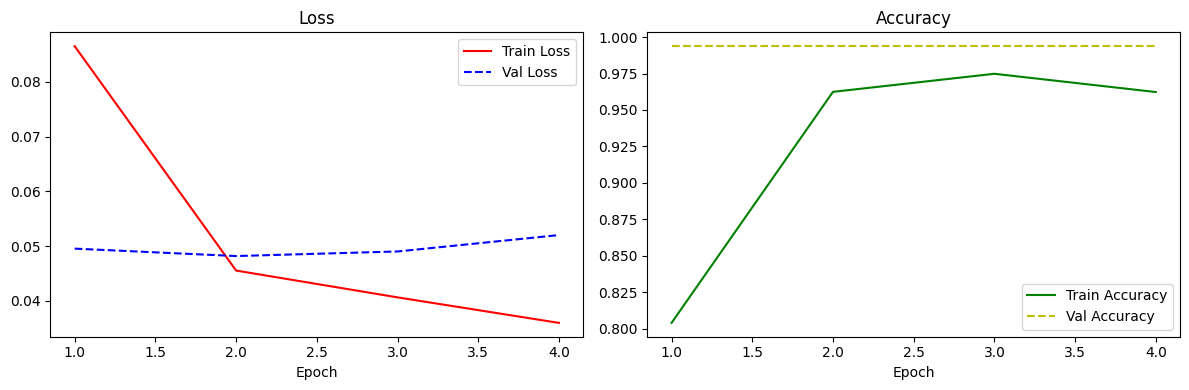

In [9]:
import matplotlib.pyplot as plt

epochs = range(1, len(history.history["loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history.history["loss"],     "r-",  label="Train Loss")
axes[0].plot(epochs, history.history["val_loss"], "b--", label="Val Loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epochs, history.history["accuracy"],     "g-",  label="Train Accuracy")
axes[1].plot(epochs, history.history["val_accuracy"], "y--", label="Val Accuracy")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

In [10]:
from sklearn.metrics import classification_report, roc_auc_score
import json

y_pred     = model.predict(X_val_seq, batch_size=256)
y_pred_bin = (y_pred > 0.5).astype(int)

print("AUC-ROC per label:")
print("-" * 40)
auc_scores = {}
for i, col in enumerate(LABEL_COLS):
    auc = roc_auc_score(y_val[:, i], y_pred[:, i])
    auc_scores[col] = round(float(auc), 4)
    print(f"  {col:20s}  AUC = {auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_pred_bin, target_names=LABEL_COLS, zero_division=0))

with open("models/metrics.json", "w") as f:
    json.dump({
        "auc": auc_scores,
        "history": {
            "loss":         [round(v,4) for v in history.history["loss"]],
            "val_loss":     [round(v,4) for v in history.history["val_loss"]],
            "accuracy":     [round(v,4) for v in history.history["accuracy"]],
            "val_accuracy": [round(v,4) for v in history.history["val_accuracy"]],
        }
    }, f, indent=2)
print("✅ metrics.json saved")

63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 214ms/step
AUC-ROC per label:
----------------------------------------
  toxic                 AUC = 0.9792
  severe_toxic          AUC = 0.9898
  obscene               AUC = 0.9895
  threat                AUC = 0.9572
  insult                AUC = 0.9825
  identity_hate         AUC = 0.9686

Classification Report:
               precision    recall  f1-score   support

        toxic       0.85      0.75      0.80      1526
 severe_toxic       0.00      0.00      0.00       158
      obscene       0.83      0.77      0.80       851
       threat       0.00      0.00      0.00        55
       insult       0.72      0.68      0.70       770
identity_hate       0.00      0.00      0.00       170

    micro avg       0.81      0.66      0.73      3530
    macro avg       0.40      0.37      0.38      3530
 weighted avg       0.72      0.66      0.69      3530
  samples avg       0.07      0.06      0.06      3530

✅ metrics.json saved


In [11]:
from utils.predict import predict_single

test_comments = [
    "You are so stupid and worthless!",
    "Thank you for the helpful explanation.",
    "I will find you and hurt you.",
    "Great work on this project!"
]

for comment in test_comments:
    result = predict_single(comment, model, tokenizer)
    status = "🚨 TOXIC" if result["is_toxic"] else "✅ CLEAN"
    print(f"{status}  →  {comment[:50]}")
    if result["is_toxic"]:
        print(f"         Dominant: {result['dominant_label']}")
        for label in LABEL_COLS:
            if result[label] > 0.3:
                print(f"         {label}: {result[label]*100:.1f}%")
    print()

🚨 TOXIC  →  You are so stupid and worthless!
         Dominant: toxic
         toxic: 96.4%
         obscene: 78.9%
         insult: 66.4%

✅ CLEAN  →  Thank you for the helpful explanation.

✅ CLEAN  →  I will find you and hurt you.

✅ CLEAN  →  Great work on this project!



In [1]:
import subprocess, threading

def run():
    subprocess.run(["streamlit", "run", "app.py"])

thread = threading.Thread(target=run, daemon=True)
thread.start()

print("✅ Streamlit is launching...")
print("👉 Open your browser and go to: http://localhost:8501")

✅ Streamlit is launching...
👉 Open your browser and go to: http://localhost:8501
